In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import PassiveAggressiveClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [2]:
fake_df = pd.read_csv(
    "dataset/Fake.csv"
)

true_df = pd.read_csv(
    "dataset/True.csv"
)

In [3]:
fake_df['label'] = 'FAKE'

true_df['label'] = 'REAL'

In [4]:
df = pd.concat(
    [fake_df, true_df],
    axis=0
)

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",FAKE
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",FAKE
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",FAKE
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",FAKE
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",FAKE


In [5]:
df = df.sample(
    frac=1,
    random_state=42
)

df.reset_index(
    drop=True,
    inplace=True
)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [7]:
df.describe()

,title,text,subject,date,label
count,44898,44898,44898,44898,44898
unique,38729,38646,8,2397,2
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",FAKE
freq,14,627,11272,182,23481


In [8]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

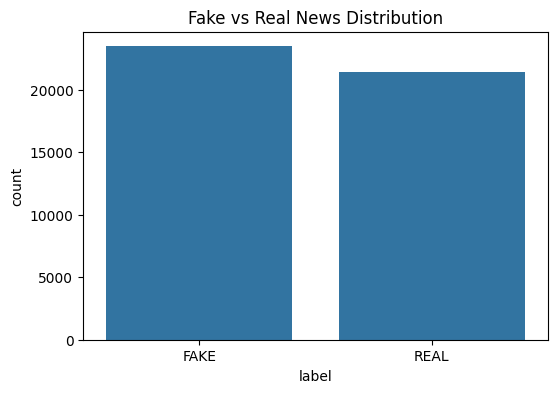

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title("Fake vs Real News Distribution")

plt.show()

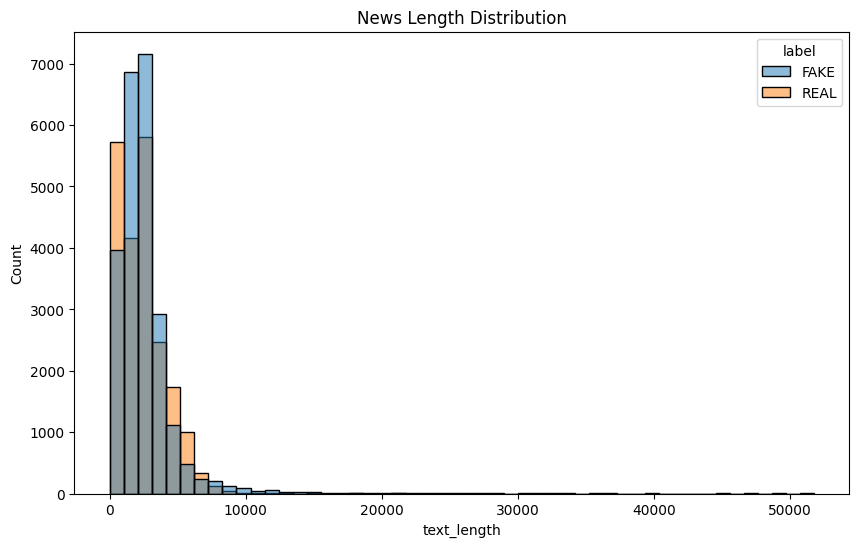

In [10]:
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='text_length',
    hue='label',
    bins=50
)

plt.title("News Length Distribution")

plt.show()

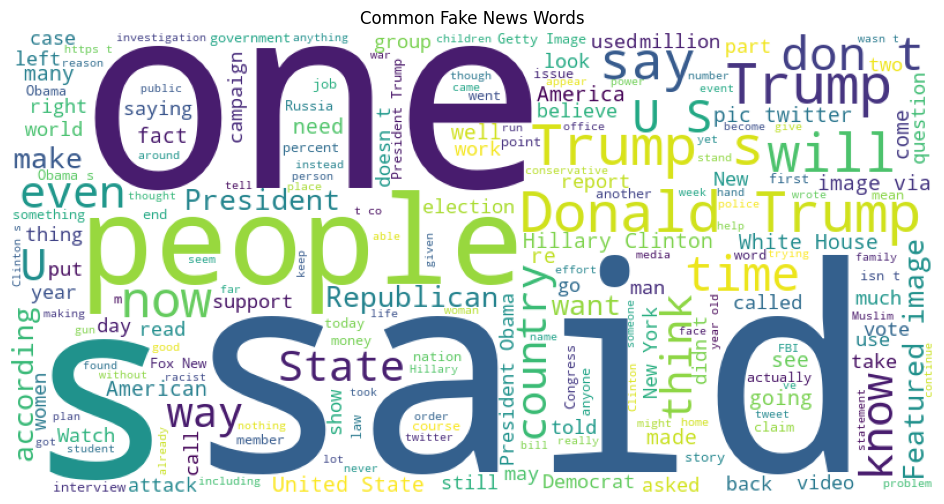

In [11]:
fake_words = ' '.join(
    list(df[df['label']=='FAKE']['text'])
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Common Fake News Words")

plt.show()

In [12]:
X = df['text']

y = df['label']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

In [37]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [38]:
model = PassiveAggressiveClassifier(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model Training Complete")

Model Training Complete


In [39]:
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

array(['FAKE', 'REAL', 'REAL', 'FAKE', 'REAL', 'REAL', 'FAKE', 'FAKE',
       'REAL', 'FAKE'], dtype='<U4')

In [31]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9929844097995546


In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[4677,   33],
       [  30, 4240]])

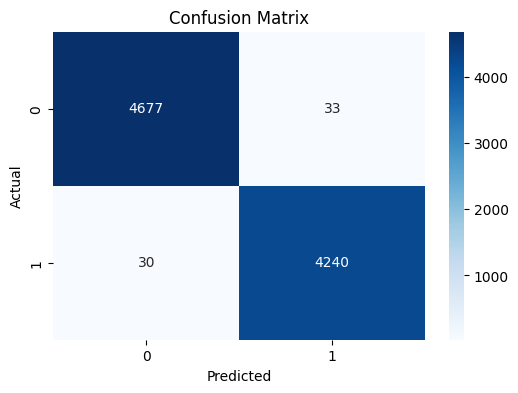

In [33]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4710
        REAL       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [35]:
sample_news = [
    "Scientists discovered dragons living underground."
]

sample_vector = vectorizer.transform(sample_news)

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: FAKE


In [40]:
from scipy.stats import ttest_ind

In [41]:
df['text_length'] = df['text'].apply(len)

df.head()

,title,text,subject,date,label,text_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE,1028
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL,4820
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL,1848
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE,1244
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL,3137


In [42]:
fake_lengths = df[df['label']=='FAKE']['text_length']

real_lengths = df[df['label']=='REAL']['text_length']

In [43]:
t_stat, p_value = ttest_ind(
    fake_lengths,
    real_lengths
)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: 8.003890245433698
P-Value: 1.2342009860075677e-15


In [44]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant difference in text lengths.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference found.")
    

Reject Null Hypothesis
There is a significant difference in text lengths.


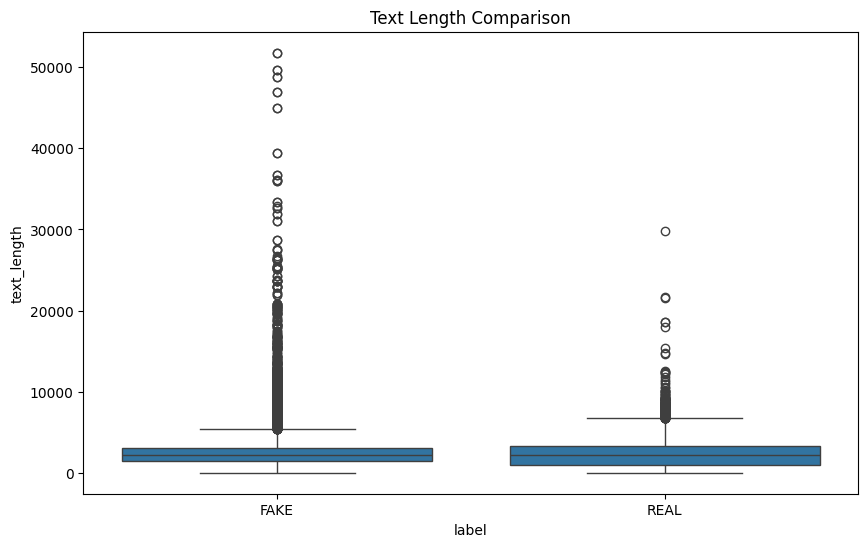

In [45]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='label',
    y='text_length',
    data=df
)

plt.title("Text Length Comparison")

plt.show()